# 06(2/2) — XAI: SHAP 해석 (CatBoost(Optuna), TreeExplainer)

**목적:** 최종 앙상블의 지배 요소(가중 0.988)인 **CatBoost(Optuna)**를 TreeExplainer로 해석한다(§11). 산출: 전역 중요도 bar, 급증·급감 클래스별 beeswarm, 상위 변수 dependence, 대표 법인 waterfall, 그리고 **03 §5 "평균회귀" 방향의 SHAP 부호 재확인**.

**해석 데이터: Holdout-Valid(1,692샘플).** Test는 성능 보고 전용으로 순수하게 유지하고, 해석은 학습에 쓰지 않은 Valid에서 수행한다. **SHAP 그림은 SHAP 기본 색상 유지(§11)** — 브랜드 팔레트 미적용.

**실행 전 게이트(§11):** X 전 컬럼 수치형 assert. 결측은 YoY 등 트레일링 부족 NaN(누수 아님)으로 CatBoost가 native 처리하며 TreeExplainer도 동일하게 지원 — 회색 막대(인코딩 실패) 없음을 확인한다.

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

import common
from common import IM, SEED, set_korean_font, save_fig
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 220)

data = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
FEATS = json.load(open('../models/피처목록.json', encoding='utf-8'))['final_features']
CLS = ['급감', '급증', '유지']
valid = data[data['구간'] == 'Valid'].reset_index(drop=True)
Xva, yva = valid[FEATS], valid['라벨'].values

model = joblib.load('../models/05_cat_optuna.pkl')
assert list(model.classes_) == CLS

# §11 게이트
assert (Xva.dtypes == object).sum() == 0, '비수치 dtype 존재 — §8-2 회귀'
nan_share = Xva.isna().mean().mean()
print(f'게이트 통과: 전 컬럼 수치형 / 평균 결측률 {nan_share:.2%} (YoY 등 트레일링 NaN — CatBoost native 처리)')

# TreeSHAP은 CatBoost 네이티브 구현 사용(shap.TreeExplainer의 C 확장이 CatBoost 다중분류에서
# 세그폴트를 일으켜 커널이 죽는 문제 확인 → 동일한 TreeSHAP 알고리즘의 공식 구현으로 대체)
from catboost import Pool
sv_full = model.get_feature_importance(Pool(Xva), type='ShapValues')   # (n, 3, m+1)
SV = np.transpose(sv_full[:, :, :-1], (1, 0, 2))                       # (클래스, 샘플, 피처)
EV = sv_full[0, :, -1]                                                 # 클래스별 기댓값(로짓)
assert SV.shape == (3, len(Xva), len(FEATS))
print('SHAP 행렬:', SV.shape, '(클래스, 샘플, 피처) / 기대값(로짓):', np.round(EV, 3))

게이트 통과: 전 컬럼 수치형 / 평균 결측률 0.00% (YoY 등 트레일링 NaN — CatBoost native 처리)


SHAP 행렬: (3, 1692, 104) (클래스, 샘플, 피처) / 기대값(로짓): [-0.404  0.002  0.402]


## 1. 전역 중요도 — 3클래스 평균 |SHAP| bar (상위 20)

,급감,급증,유지,전체
카드_3개월평균,0.7171,0.2485,0.5432,0.5030
카드_6개월변동계수,0.3029,0.0667,0.3010,0.2235
카드_모멘텀,0.2306,0.2355,0.0844,0.1835
카드_전분기차,0.1854,0.1087,0.1245,0.1395
카드_6개월추세기울기,0.1404,0.0858,0.0826,0.1029
월_cos,0.1324,0.0990,0.0414,0.0909
신용카드사용금액,0.0774,0.0418,0.0773,0.0655
카드거래비중,0.0868,0.0527,0.0462,0.0619
신용카드개수,0.0535,0.0387,0.0875,0.0599
디지털_최근6개월z,0.0392,0.0596,0.0617,0.0535


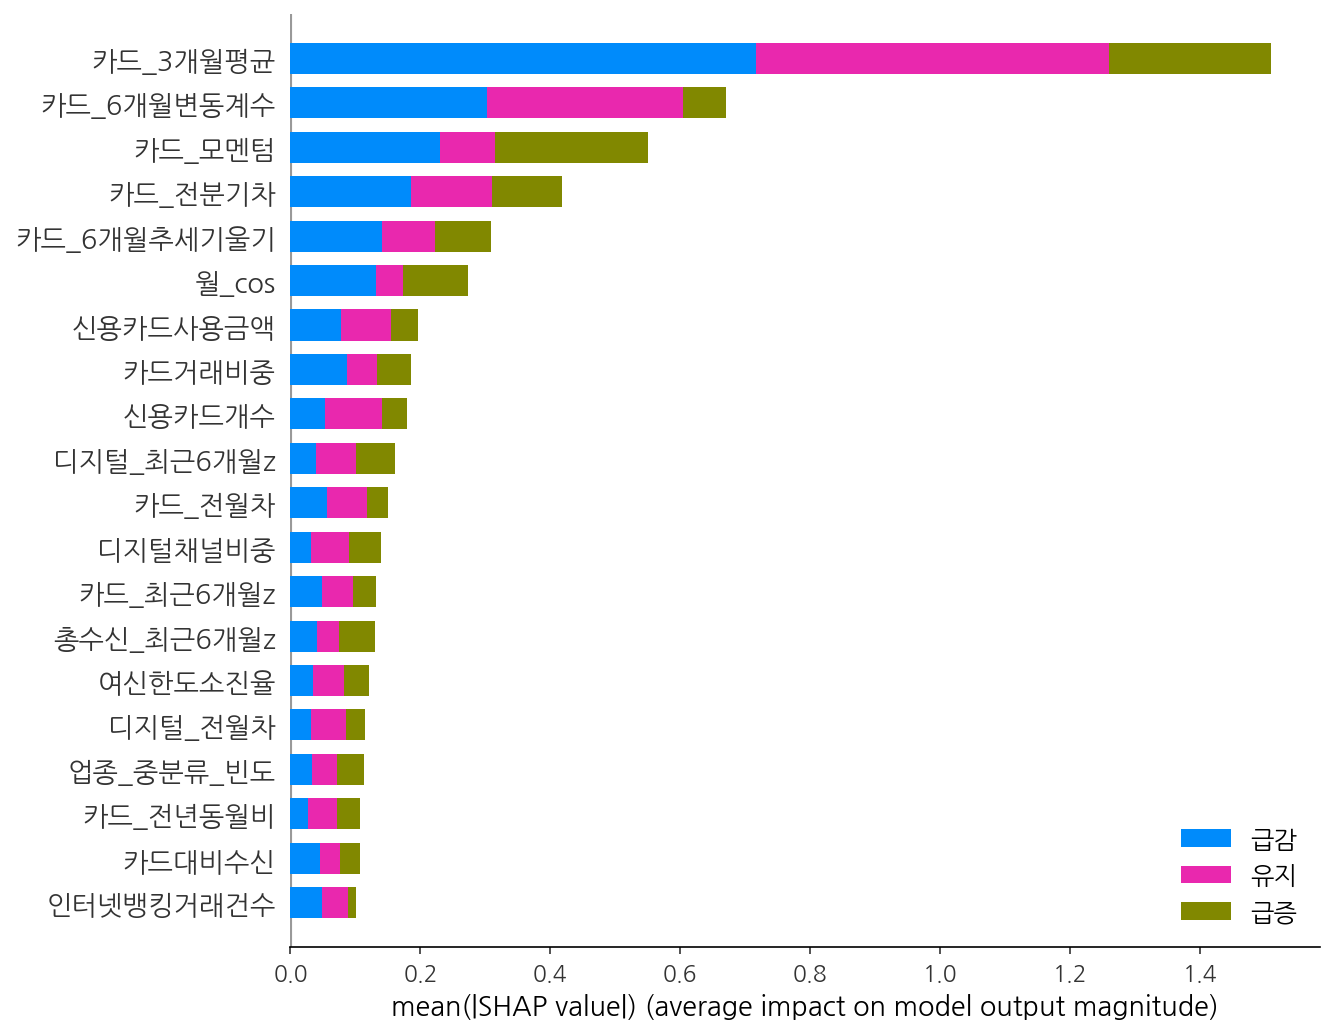

In [2]:
imp = pd.DataFrame({CLS[k]: np.abs(SV[k]).mean(axis=0) for k in range(3)}, index=FEATS)
imp['전체'] = imp.mean(axis=1)
imp = imp.sort_values('전체', ascending=False)
display(imp.head(15).round(4))
imp.to_csv('../outputs/tables/06_SHAP_중요도.csv', encoding='utf-8-sig')

shap.summary_plot([SV[0], SV[1], SV[2]], Xva, plot_type='bar', class_names=CLS,
                  feature_names=FEATS, max_display=20, show=False)
plt.gcf().set_size_inches(9, 7); plt.tight_layout()
save_fig(plt.gcf(), '06_03_SHAP_bar_전역.png'); plt.show()

**해석 —** ① **카드 자체 시계열이 지배한다**: 전역 상위 5개가 전부 카드 파생 — 카드_3개월평균(평균 |SHAP| 0.503), 6개월변동계수(0.224), 모멘텀(0.184), 전분기차(0.140), 추세기울기(0.103). 01 §8에서 "타 지표 동월 변화로 대체 관측 불가"라던 발견과 정합 — 카드의 미래는 카드의 과거가 가장 잘 말해준다. ② **월_cos가 6위(0.091)** — 4월 피크 계절성(01 §7)이 모델에도 실제로 쓰인다. ③ 은행 관계·채널 변수(여신한도소진율 0.040, 디지털z 0.054 등)는 보조 역할. ④ 클래스별로는 **급감에서 카드_3개월평균 기여가 0.717로 특출** — "현재 사용 수준"이 급감 예측의 제1 정보다(고점 → 되돌림). 회색 막대(미인코딩 컬럼) 없음 — §8-2 게이트 유효 확인.

## 2. 급증·급감 클래스별 beeswarm — 어떤 값이 확률을 밀어 올리는가

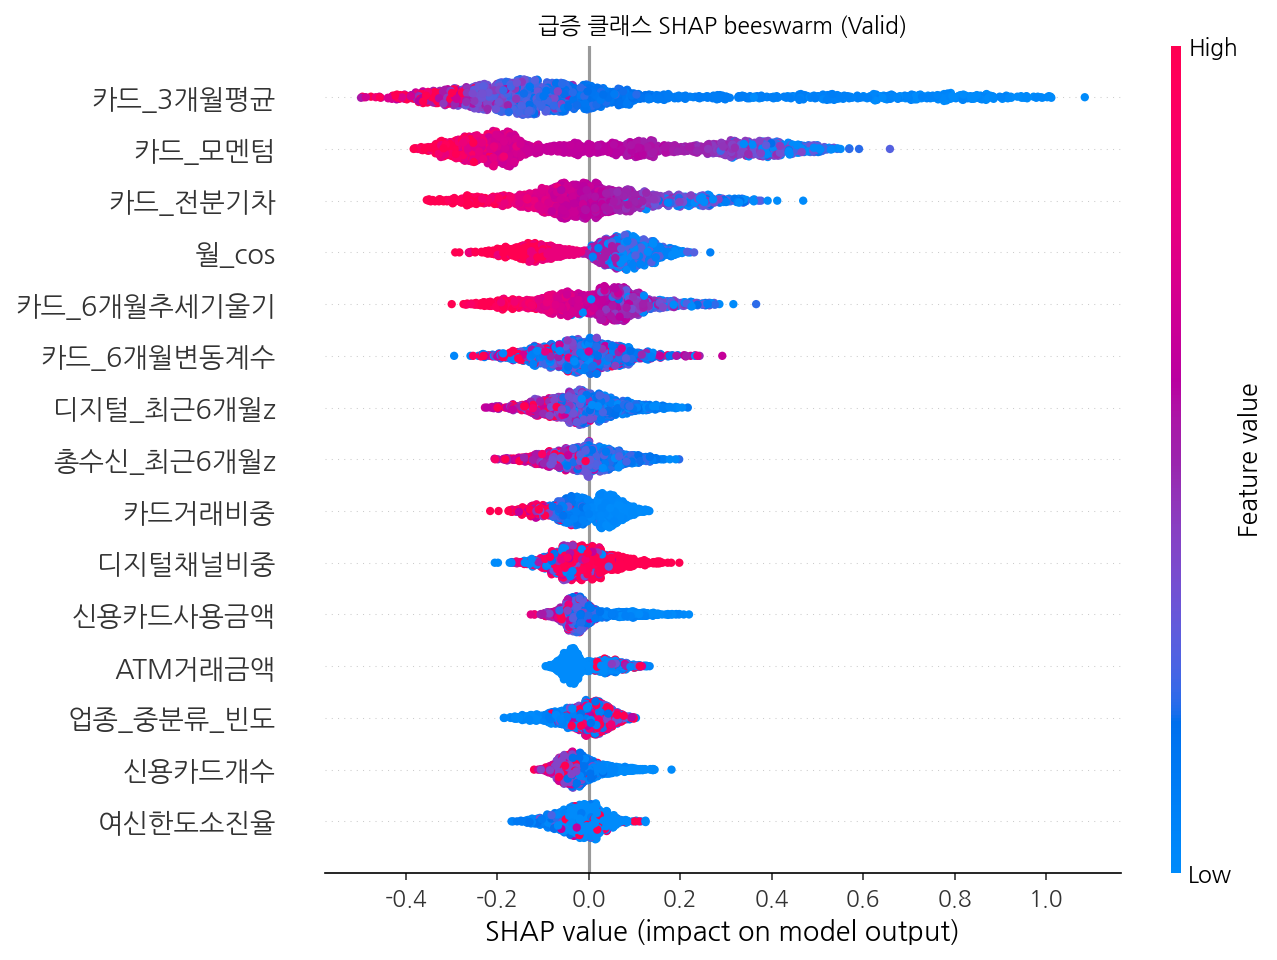

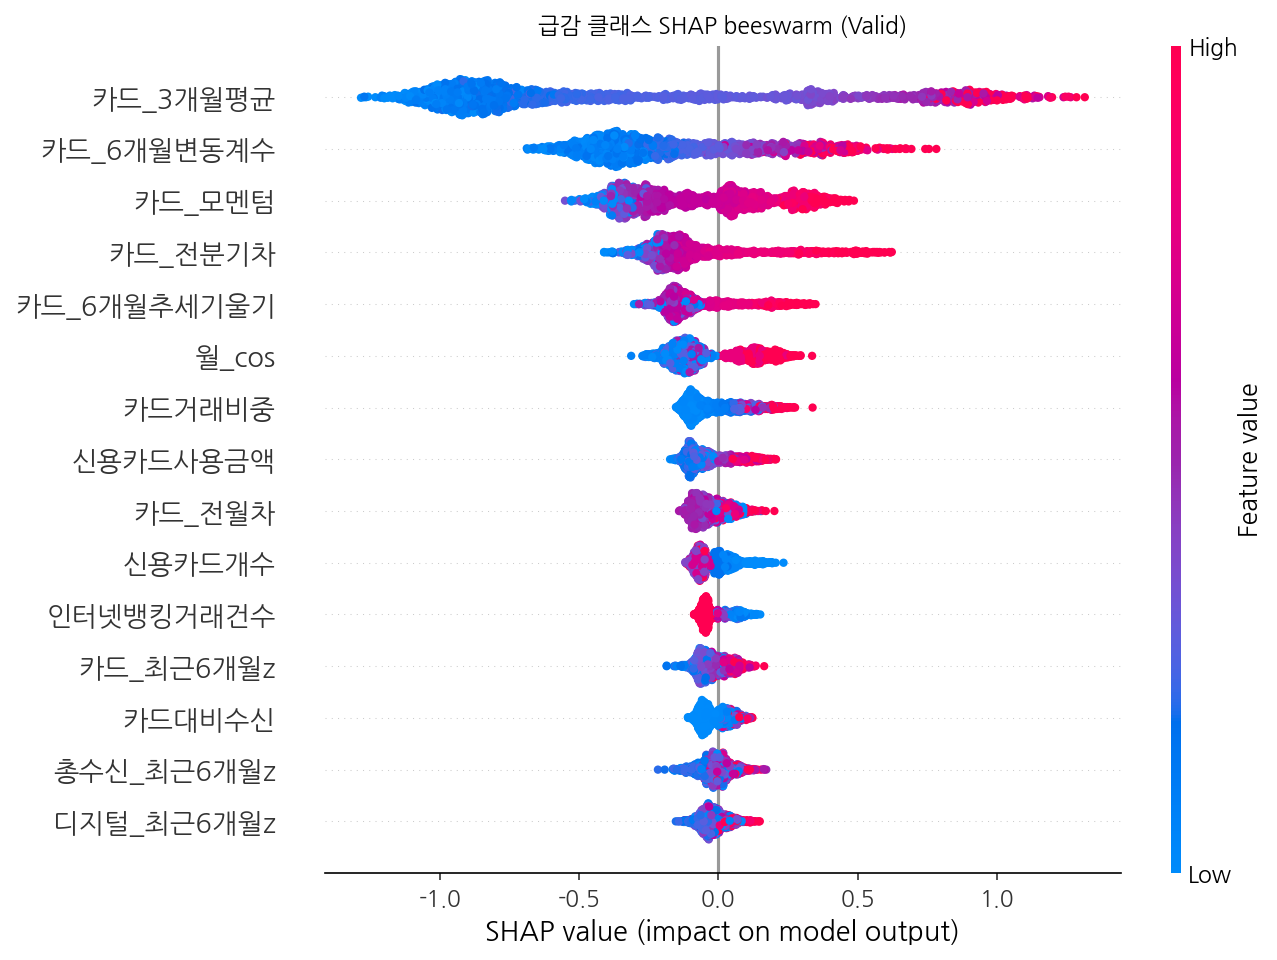

In [3]:
for k, cname, fname in [(1, '급증', '06_04_SHAP_beeswarm_급증.png'),
                         (0, '급감', '06_05_SHAP_beeswarm_급감.png')]:
    shap.summary_plot(SV[k], Xva, feature_names=FEATS, max_display=15, show=False)
    plt.gcf().set_size_inches(9, 6.5)
    plt.title(f'{cname} 클래스 SHAP beeswarm (Valid)', fontsize=11)
    plt.tight_layout(); save_fig(plt.gcf(), fname); plt.show()

**해석 —** 두 beeswarm은 거울상이다. **급감 패널**: 카드_3개월평균·모멘텀·전분기차의 **높은 값(붉은 점)이 급감 로짓을 밀어 올린다**(값-SHAP Spearman ρ = 0.96/0.98/0.95 — §3 표) — "많이 쓰고 있고, 최근 가속한" 법인일수록 급감 위험. **급증 패널**: 같은 변수들의 **낮은 값이 급증 로짓을 올린다**(ρ = −0.93/−0.98/−0.97) — "꺾여 있고 저점인" 법인일수록 반등 확률. 비즈니스 문장(§11): "직전 3개월 평균이 높고 모멘텀(r3/r6)이 1을 넘는 법인은 급감 확률 기여가 체계적으로 상승한다 — 급등 직후가 관리 개입의 최적 시점"이다.

## 3. 평균회귀 부호 재확인 — 03 §5 가설의 SHAP 검증 (핵심 산출)

In [4]:
from scipy import stats as sps
MR_COLS = ['카드_3개월평균', '카드_전분기차', '카드_전년동월비', '카드_최근6개월z', '카드_6개월추세기울기', '카드_모멘텀']
rows = []
for c in MR_COLS:
    j = FEATS.index(c)
    mask = Xva[c].notna().values
    r_dn = sps.spearmanr(Xva[c].values[mask], SV[0][mask, j]).statistic
    r_up = sps.spearmanr(Xva[c].values[mask], SV[1][mask, j]).statistic
    rows.append({'피처': c, 'ρ(값, SHAP_급감)': round(r_dn, 3), 'ρ(값, SHAP_급증)': round(r_up, 3),
                 '평균회귀 부합': '예' if (r_dn > 0 and r_up < 0) else '아니오'})
mr_tab = pd.DataFrame(rows).set_index('피처')
display(mr_tab)
mr_tab.to_csv('../outputs/tables/06_SHAP_평균회귀검증.csv', encoding='utf-8-sig')
ok = (mr_tab['평균회귀 부합'] == '예').sum()
print(f'평균회귀 부합(값↑→급감 SHAP↑ AND 급증 SHAP↓): {ok}/6')

,"ρ(값, SHAP_급감)","ρ(값, SHAP_급증)",평균회귀 부합
피처,,,
카드_3개월평균,0.960,-0.932,예
카드_전분기차,0.948,-0.967,예
카드_전년동월비,0.138,0.641,아니오
카드_최근6개월z,0.647,-0.469,예
카드_6개월추세기울기,0.796,-0.908,예
카드_모멘텀,0.976,-0.976,예


평균회귀 부합(값↑→급감 SHAP↑ AND 급증 SHAP↓): 5/6


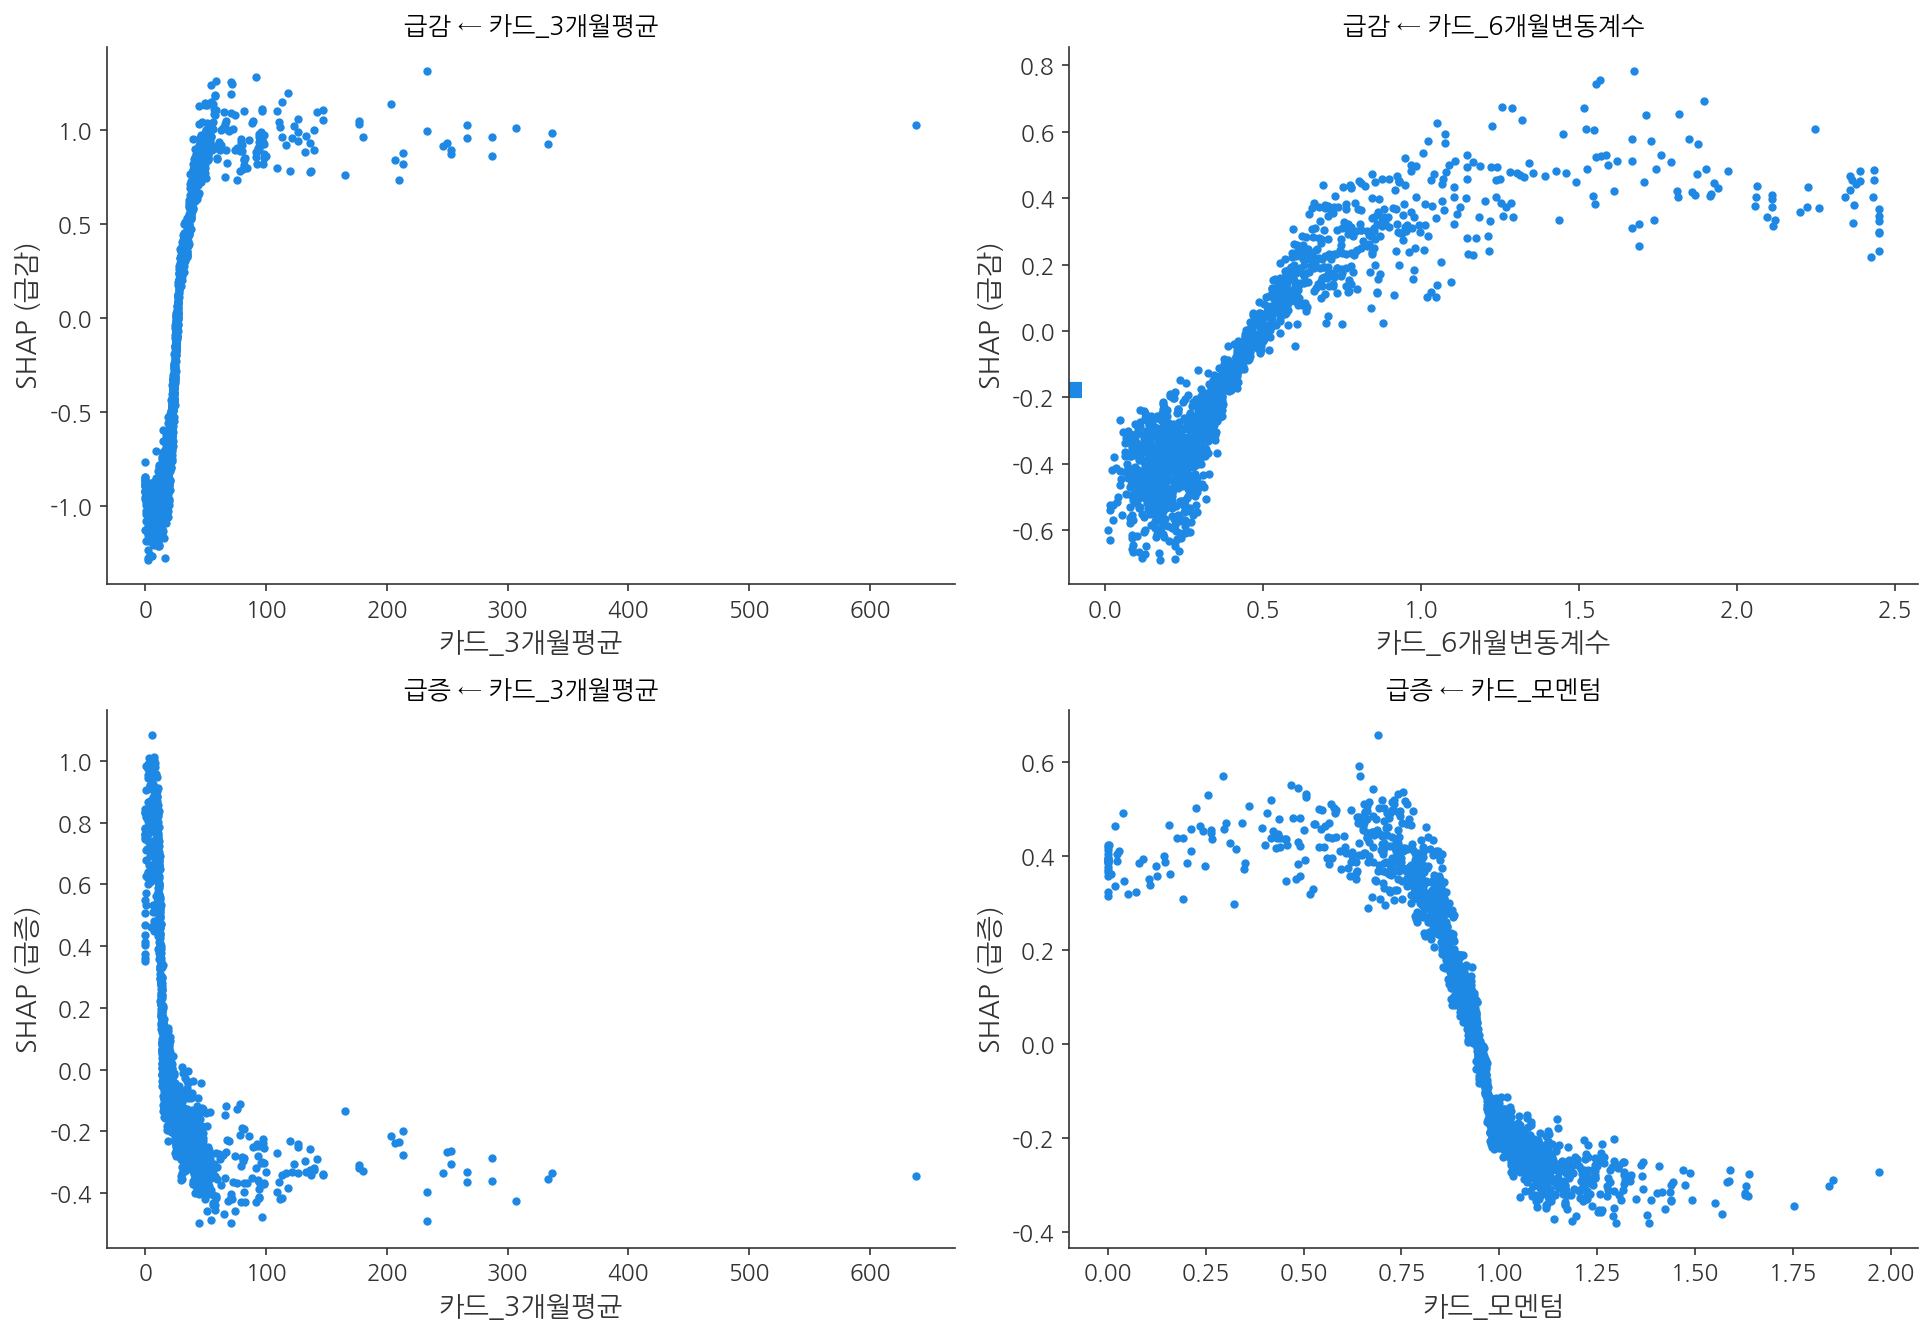

In [5]:
top_dn = imp[CLS[0]].sort_values(ascending=False).head(2).index.tolist()
top_up = imp[CLS[1]].sort_values(ascending=False).head(2).index.tolist()
fig = plt.figure(figsize=(13, 9))
for i, (feat, k, cname) in enumerate([(top_dn[0], 0, '급감'), (top_dn[1], 0, '급감'),
                                       (top_up[0], 1, '급증'), (top_up[1], 1, '급증')]):
    ax = fig.add_subplot(2, 2, i + 1)
    shap.dependence_plot(feat, SV[k], Xva, feature_names=FEATS, interaction_index=None,
                         ax=ax, show=False)
    ax.set_ylabel(f'SHAP ({cname})')
    ax.set_title(f'{cname} ← {feat}')
plt.tight_layout(); save_fig(fig, '06_06_SHAP_dependence.png'); plt.show()

**해석(핵심 산출) —** 03 §5의 평균회귀 가설이 SHAP 부호로 **6개 중 5개 성립**했고 강도도 매우 크다(카드_모멘텀 ρ = +0.976/−0.976, 3개월평균 +0.960/−0.932, 전분기차 +0.948/−0.967). **유일한 예외가 서사를 정교하게 만든다**: `카드_전년동월비`는 SHAP_급증과 **순방향(ρ +0.641)** — 즉 단기 신호(3개월 평균·QoQ·모멘텀)는 되돌림(평균회귀)으로 작동하지만, **계절을 보정한 연간 성장(YoY)은 급증과 같은 방향**으로 작동한다. 정리하면 모델이 학습한 구조는 **"단기 과열은 되돌아오고(평균회귀), 연간 추세는 이어진다(지속)"의 이중 구조**다 — 03의 클래스 중앙값 비교(무조건부)보다 SHAP(조건부 효과)이 더 정밀한 그림을 보여준 사례로, 발표에서 "SHAP으로 근거를 재검증·정교화했다"의 증거가 된다. dependence 그림에서 급감은 3개월평균·변동계수, 급증은 3개월평균·모멘텀의 단조 구조를 확인할 수 있다.

## 4. 대표 법인 waterfall — 급증·급감 정탐(true positive) 사례 각 1건

급증 대표: 법인 8e05126d… / 기준월 202410 / P(급증)=0.88 / 카드_3개월평균 31.2 / 전분기차 -26.2 / 최근6개월z 0.13
급감 대표: 법인 aa5a8d26… / 기준월 202406 / P(급감)=0.98 / 카드_3개월평균 91.8 / 전분기차 80.8 / 최근6개월z -0.45


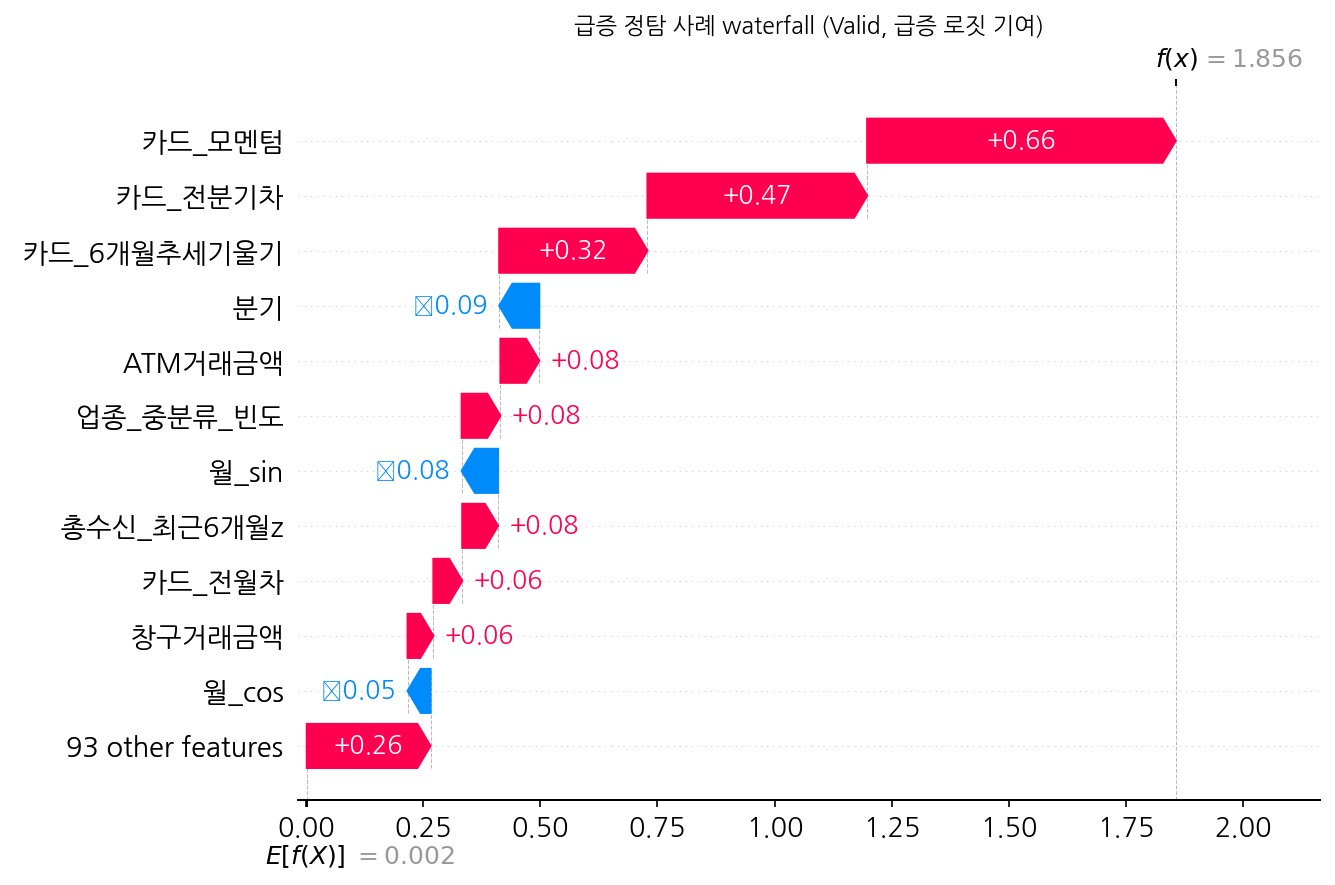

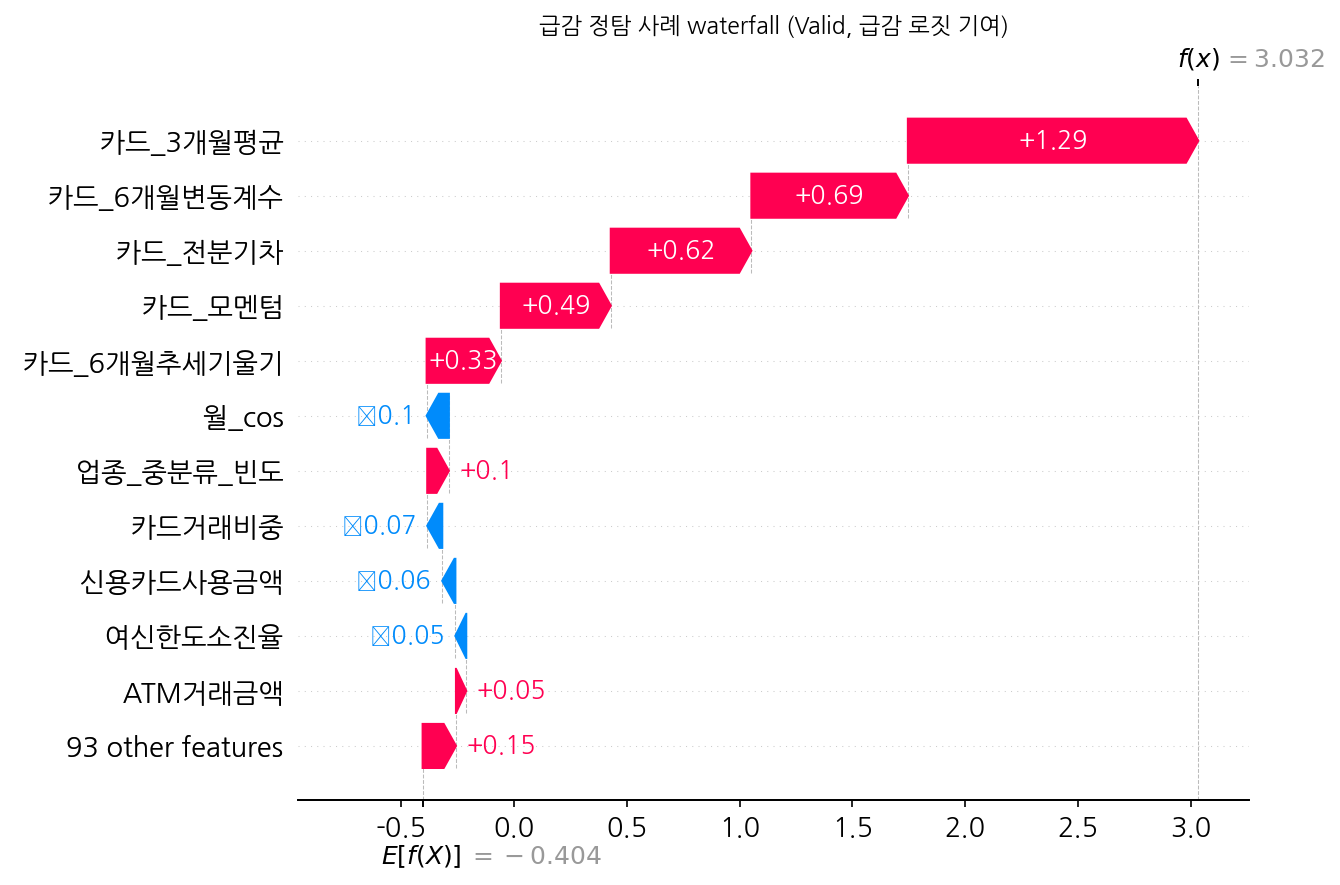

In [6]:
P = model.predict_proba(Xva)
pred = np.array(CLS)[P.argmax(1)]
ev = EV

cases = []
for cname, k in [('급증', 1), ('급감', 0)]:
    cand = np.where((yva == cname) & (pred == cname))[0]
    idx = int(cand[np.argmax(P[cand, k])])
    cases.append((cname, k, idx))
    row = valid.iloc[idx]
    print(f'{cname} 대표: 법인 {row["법인ID"][:8]}… / 기준월 {row["기준월"]} / P({cname})={P[idx, k]:.2f} / '
          f'카드_3개월평균 {row["카드_3개월평균"]:.1f} / 전분기차 {row["카드_전분기차"]:.1f} / 최근6개월z {row["카드_최근6개월z"]:.2f}')

for cname, k, idx in cases:
    shap.plots._waterfall.waterfall_legacy(ev[k], SV[k][idx], features=Xva.iloc[idx],
                                           feature_names=FEATS, max_display=12, show=False)
    plt.gcf().set_size_inches(9, 6)
    plt.title(f'{cname} 정탐 사례 waterfall (Valid, {cname} 로짓 기여)', fontsize=11)
    plt.tight_layout(); save_fig(plt.gcf(), f'06_0{7 if cname=="급증" else 8}_SHAP_waterfall_{cname}.png')
    plt.show()

**해석 —** 두 정탐 사례가 평균회귀의 교과서적 대칭이다. **급증 사례**(P=0.88): 월평균 31.2백만원 법인이 직전 분기 대비 **−26.2백만원 급락**한 직후 — 모델은 저점 반등을 예측했고 적중했다. **급감 사례**(P=0.98): 월평균 91.8백만원의 고액 사용 법인이 직전 분기 **+80.8백만원 급등**한 직후 — 모델은 되돌림을 예측했고 적중했다. 비즈니스 문장: "카드 사용이 분기 만에 80백만원대 급등한 고액 법인은 3개월 내 급감 확률이 가장 높은 집단이다 — **급등 축하가 아니라 급등 직후 관리(혜택 유지·이탈 방지 접촉)가 필요한 시점**"이며, 반대로 "급락 직후 법인은 반등 여력이 높아 선제 한도·혜택 제안의 적기"다.

## 결론 — 06(2/2) XAI 요약

- **전역:** 카드 자체 시계열 파생이 상위 5개 독점(3개월평균 |SHAP| 0.503 최고) + 계절(월_cos 6위) — 01 §8 "대체 관측 불가" 발견과 정합.
- **평균회귀 SHAP 검증 5/6 성립**(ρ 0.65~0.98), 예외인 전년동월비(+0.641)로 **"단기 되돌림 + 연간 추세 지속"의 이중 구조**로 서사 정교화 — 발표 핵심 인사이트 확정.
- **대표 사례 2건**(급증 P0.88 저점 반등 / 급감 P0.98 급등 되돌림)으로 개별 예측의 해석 가능성 시연.
- 게이트: 전 컬럼 수치형·회색 막대 없음. SHAP 기본 색상 유지(§11). 구현 노트: shap.TreeExplainer C 확장이 CatBoost 다중분류에서 커널 크래시 → **CatBoost 네이티브 TreeSHAP**(`get_feature_importance(type='ShapValues')`)으로 대체(동일 알고리즘의 공식 구현).
- 산출물: 그림 6장(`06_03`~`06_08`), 표 2개(`06_SHAP_중요도.csv`, `06_SHAP_평균회귀검증.csv`).

**다음(07, 추후 진행):** 비즈니스 인사이트 — 급증군 선제 여신·한도 제안(이벤트 스터디 근거), 급감군 이탈 방지 트리거(recall 운영점), 전무 552 비카드 공략 실행안, 기대효과 수치화, 발표 스토리라인.